# RACE Dataset â€” Exploratory Data Analysis

Session 1 EDA. Run after `python src/preprocessing.py` has produced the split files.

**Sections:**
1. Load splits
2. Sample rows
3. Answer distribution (A/B/C/D)
4. Article length distribution (word count)
5. Question length distribution (word count)
6. Summary statistics table

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

DATA_DIR = os.path.join('..', 'data')
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_split.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_split.csv'))

print(f'Train: {len(train_df):>6} rows')
print(f'Val:   {len(val_df):>6} rows')
print(f'Test:  {len(test_df):>6} rows')
print(f'Columns: {list(train_df.columns)}')

Train:  70292 rows
Val:     8787 rows
Test:    8787 rows
Columns: ['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


## 1. Sample rows

In [2]:
train_df.head(5)

,Unnamed: 0,id,article,question,A,B,C,D,answer
0,20564,middle1585.txt,Walt Disney began to make cartoon movies when he was young. But he didn't have much money and he didn't always have ...,"When Disney began making cartoon movies, _ .",he was very poor,the mouse helped him,his wife knew nothing about it,People didn't like Cartoons at all,A
1,17933,middle178.txt,"How could we live without the Internet? That's how most of us keep in touch with friends, find homework support, res...",The Internet is an unsafe place because _ .,There are many illegal things,Your personal information may be given away.,The computers may be harmed,Your e-mail address might be changed,B
2,40128,high4587.txt,George Zinunerman's first court appearance before a Florida judge came on Tuesday inconnection with the shooting of ...,What's Angela Corey's attitude towards this case?,She showed sympathy for the black people.,She wanted to defend justice for the victims.,She hated George Zimmerman very much,She was against self-defense.,B
3,81923,high23034.txt,Forks trace their origins back to the ancient Greeks. Forks at that time were fairly large with two tines that aid...,How did forks become popular in England?,Wealthy British were impressed by the design of forks.,Wealthy British thought it awkward to use their hands to eat.,Wealthy British gave special forks to the nobles as luxurious gifts.,Wealthy British considered dining with forks a sign of social status.,D
4,49069,high8839.txt,"On hearing the words ""Just do it!"", you will know there is a Nike product nearby. If it's ""Always Coca-Cola"", you ca...",What would be the best title for the text?,Just Do It!,Slogan And Brand,Famous Slogans,What is a Good Slogan.,B


In [3]:
for i, row in train_df.head(3).iterrows():
    print(f'--- Sample {i} ---')
    print('Article:', str(row['article'])[:300], '...')
    print('Question:', row['question'])
    print('A:', row['A'])
    print('B:', row['B'])
    print('C:', row['C'])
    print('D:', row['D'])
    print('Answer:', row['answer'])
    print()

--- Sample 0 ---
Article: Walt Disney began to make cartoon movies when he was young. But he didn't have much money and he didn't always have enough to eat. One day a mouse ran near his desk when he worked in his small office.
"Would you like to be my pet? "Disney asked the mouse. He caught the mouse and kept it as a pet. A  ...
Question: When Disney began making cartoon movies,  _  .
A: he was very poor
B: the mouse helped him
C: his wife knew nothing about it
D: People didn't like Cartoons at all
Answer: A

--- Sample 1 ---
Article: How could we live without the Internet? That's how most of us keep in touch with friends, find homework support, research cool place to visit, or find out the latest news. You can use it to do research for school, find out what movie is on near you, check out a college you're thinking about, or find ...
Question: The Internet is an unsafe place because  _  .
A: There are many illegal things
B: Your personal information may be given away.
C: The computers 

## 2. Answer distribution (A / B / C / D)

answer
A    15257
B    18141
C    19091
D    17803
Name: count, dtype: int64


C:\Users\Victus\AppData\Local\Temp\ipykernel_14708\1956536230.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=answer_counts.index, y=answer_counts.values, ax=ax, palette='viridis')


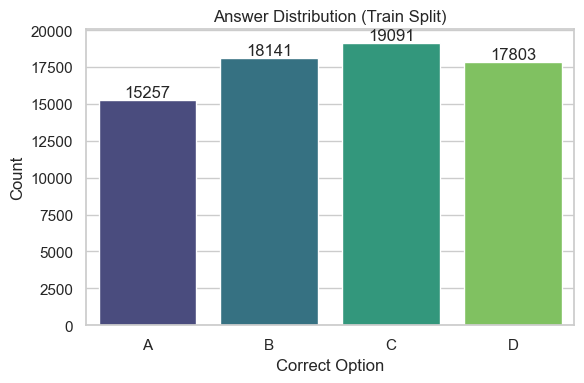

In [4]:
answer_counts = train_df['answer'].value_counts().sort_index()
print(answer_counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=answer_counts.index, y=answer_counts.values, ax=ax, palette='viridis')
ax.set_title('Answer Distribution (Train Split)')
ax.set_xlabel('Correct Option')
ax.set_ylabel('Count')
for i, v in enumerate(answer_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 3. Article length distribution (word count)

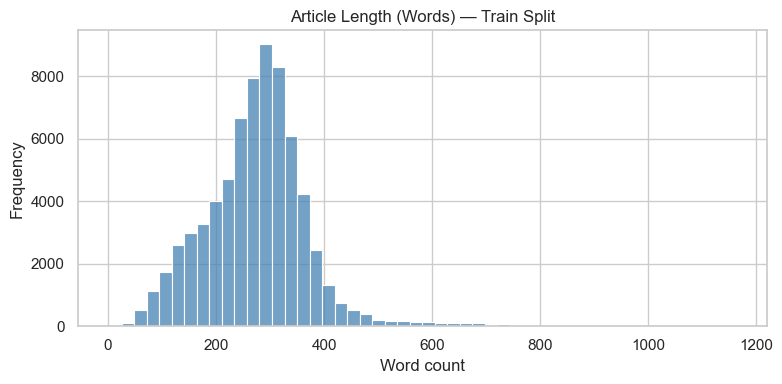

In [5]:
train_df['article_word_count'] = train_df['article'].astype(str).str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train_df['article_word_count'], bins=50, ax=ax, color='steelblue')
ax.set_title('Article Length (Words) â€” Train Split')
ax.set_xlabel('Word count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 4. Question length distribution (word count)

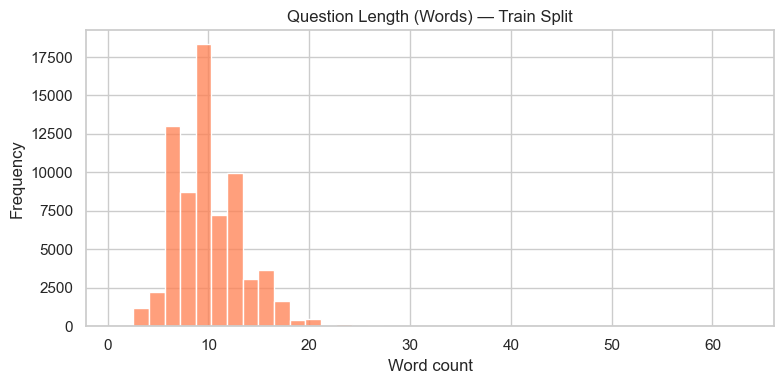

In [6]:
train_df['question_word_count'] = train_df['question'].astype(str).str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train_df['question_word_count'], bins=40, ax=ax, color='coral')
ax.set_title('Question Length (Words) â€” Train Split')
ax.set_xlabel('Word count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 5. Summary statistics (mean / median / min / max)

In [7]:
for col in ['A', 'B', 'C', 'D']:
    train_df[f'{col}_word_count'] = train_df[col].astype(str).str.split().str.len()

summary = pd.DataFrame({
    'article':  train_df['article_word_count'].describe()[['mean', '50%', 'min', 'max']],
    'question': train_df['question_word_count'].describe()[['mean', '50%', 'min', 'max']],
    'option_A': train_df['A_word_count'].describe()[['mean', '50%', 'min', 'max']],
    'option_B': train_df['B_word_count'].describe()[['mean', '50%', 'min', 'max']],
    'option_C': train_df['C_word_count'].describe()[['mean', '50%', 'min', 'max']],
    'option_D': train_df['D_word_count'].describe()[['mean', '50%', 'min', 'max']],
}).T
summary.columns = ['mean', 'median', 'min', 'max']
summary = summary.round(2)
summary

,mean,median,min,max
article,274.75,279.0,2.0,1162.0
question,10.01,10.0,1.0,63.0
option_A,5.44,5.0,1.0,91.0
option_B,5.64,5.0,1.0,105.0
option_C,5.80,6.0,1.0,48.0
option_D,5.93,6.0,1.0,67.0


In [8]:
print('Missing values per column (train):')
print(train_df[['article', 'question', 'A', 'B', 'C', 'D', 'answer']].isna().sum())

Missing values per column (train):
article     0
question    0
A           3
B           0
C           1
D           9
answer      0
dtype: int64


<!-- session-3-visualizations -->
# Session 3 — Visualizations
Confusion matrices, model comparison, and a 2D PCA scatter of the K-Means clusters.


In [1]:
import os, json, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import scipy.sparse as sp
from sklearn.decomposition import TruncatedSVD

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODELS = os.path.join(ROOT, 'models')
DATA = os.path.join(ROOT, 'data')
FIG_DIR = os.path.join(ROOT, 'notebooks', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

with open(os.path.join(MODELS, 'model_a_metrics.json')) as f:
    metrics = json.load(f)
metrics_df = pd.DataFrame(metrics)[['name', 'accuracy', 'macro_f1', 'exact_match']]
metrics_df


,name,accuracy,macro_f1,exact_match
0,Logistic Regression,0.670963,0.540839,0.308183
1,LinearSVC (calibrated),0.668971,0.538059,0.303972
2,ComplementNB,0.662940,0.529642,0.294754
3,Ensemble (avg),0.672784,0.543380,0.311369


## Confusion matrices (LR / SVC / NB)

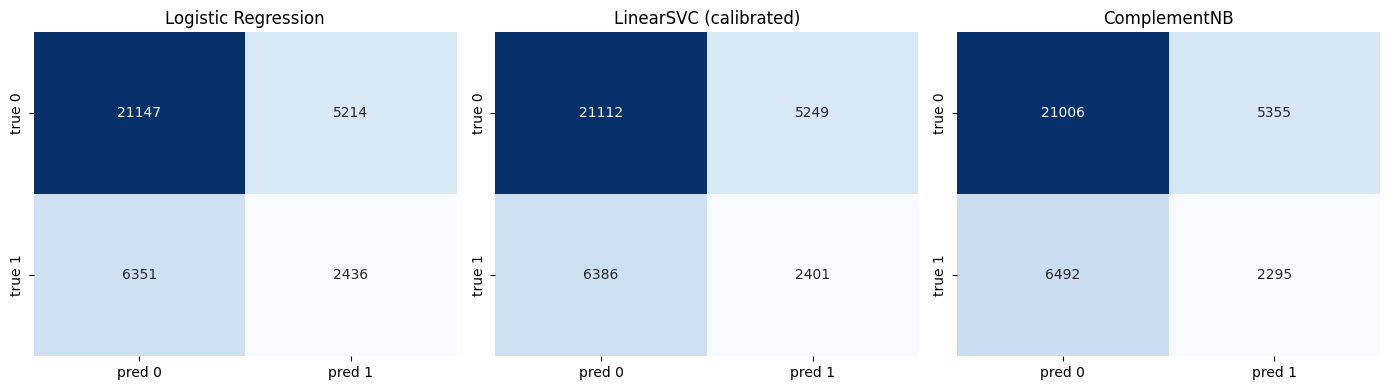

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
names = ['Logistic Regression', 'LinearSVC (calibrated)', 'ComplementNB']
for ax, name in zip(axes, names):
    cm = next(m for m in metrics if m['name'] == name)['confusion_matrix']
    sns.heatmap(np.array(cm), annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['pred 0', 'pred 1'],
                yticklabels=['true 0', 'true 1'], ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrices.png'), dpi=140)
plt.show()


## Model comparison — Macro F1 vs Exact Match

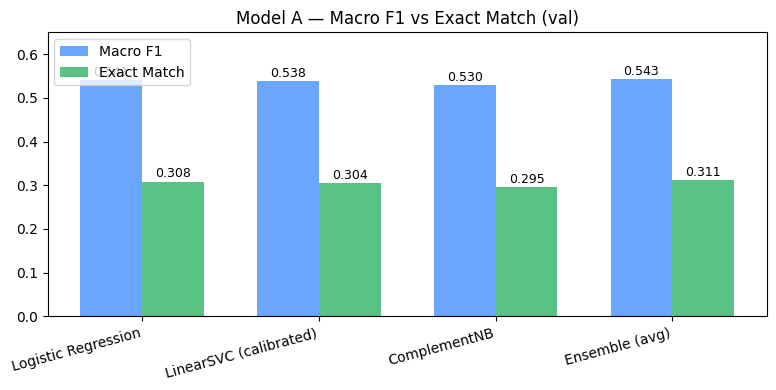

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metrics_df)); w = 0.35
ax.bar(x - w/2, metrics_df['macro_f1'], w, label='Macro F1', color='#6aa6ff')
ax.bar(x + w/2, metrics_df['exact_match'], w, label='Exact Match', color='#59c285')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['name'], rotation=15, ha='right')
ax.set_ylim(0, 0.65)
ax.legend(loc='upper left')
ax.set_title('Model A — Macro F1 vs Exact Match (val)')
for i, (f1, em) in enumerate(zip(metrics_df['macro_f1'], metrics_df['exact_match'])):
    ax.text(i - w/2, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, em + 0.01, f'{em:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison.png'), dpi=140)
plt.show()


## 2D PCA of TF-IDF features, coloured by K-Means cluster (5k sample)

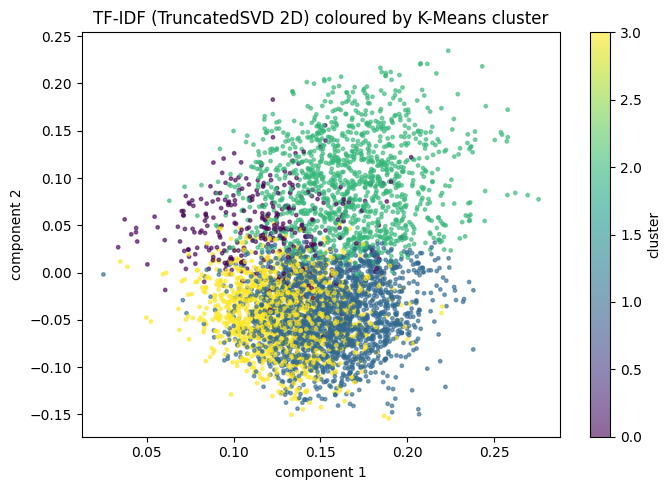

In [4]:
X_train = sp.load_npz(os.path.join(DATA, 'X_train.npz'))
rng = np.random.RandomState(0)
idx = rng.choice(X_train.shape[0], size=5000, replace=False)
X_sub = X_train[idx]

km = joblib.load(os.path.join(MODELS, 'kmeans.pkl'))
clusters = km.predict(X_sub)

svd = TruncatedSVD(n_components=2, random_state=42)
X2 = svd.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=clusters, cmap='viridis', s=6, alpha=0.6)
ax.set_title('TF-IDF (TruncatedSVD 2D) coloured by K-Means cluster')
ax.set_xlabel('component 1'); ax.set_ylabel('component 2')
plt.colorbar(scatter, ax=ax, label='cluster')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'kmeans_pca.png'), dpi=140)
plt.show()
